In [495]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold,cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, 
                             f1_score, roc_auc_score, roc_curve, auc, make_scorer)

from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE



## 1. Load Data & Merged Data

In [496]:
songs_labeled = pd.read_csv('songs_aggregated_labeled.csv', sep=';')

songs_labeled['first_appearance'] = pd.to_datetime(songs_labeled['first_appearance'])
songs_labeled['last_appearance'] = pd.to_datetime(songs_labeled['last_appearance'])

print(f"  Total songs: {len(songs_labeled):,}")
print(f"  Training:    {songs_labeled['is_train'].sum():,}")
print(f"  Test:        {(~songs_labeled['is_train']).sum():,}")

songs_labeled.head()

  Total songs: 9,161
  Training:    7,572
  Test:        1,589


,id,best_rank,avg_rank,total_weeks_charted,first_appearance,last_appearance,Title,Artist,peak_score,longevity_score,popularity_score,popularity_label,is_train
0,000xQL6tZNLJzIrtIgxqSl,40,101.500000,118,2017-03-24,2017-09-12,Still Got Time (feat. PARTYNEXTDOOR),ZAYN,80.5,100.0,92.2,Popular,True
1,003VDDA7J3Xb2ZFlNx7nIZ,108,138.000000,2,2020-02-07,2020-02-08,YELL OH,Trippie Redd,46.5,10.0,24.6,Not Popular,True
2,003eoIwxETJujVWmNFMoZy,91,136.500000,14,2018-06-15,2018-06-28,Growing Pains,Alessia Cara,55.0,70.0,64.0,Not Popular,True
3,003vvx7Niy0yvhvHt4a68B,73,173.794872,273,2020-08-15,2021-12-31,Mr. Brightside,The Killers,64.0,100.0,85.6,Popular,True
4,00B7TZ0Xawar6NZ00JFomN,61,109.285714,14,2018-04-06,2018-04-19,Best Life (feat. Chance The Rapper),Cardi B,70.0,70.0,70.0,Not Popular,True


In [497]:
df_song_charts = pd.read_csv("final_cleaned_data.csv", sep=';')
df_song_charts['Date'] = pd.to_datetime(df_song_charts['Date'])
audio_features = df_song_charts.groupby('id')[['Danceability', 'Energy', 'Loudness_norm', 
                                                    'Speechiness', 'Acousticness', 
                                                    'Instrumentalness',  'Valence'
                                                    ]].first().reset_index()

In [498]:
merged_df_spotify = songs_labeled.merge(audio_features, on='id', how='inner')
merged_df_spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9161 entries, 0 to 9160
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   9161 non-null   object        
 1   best_rank            9161 non-null   int64         
 2   avg_rank             9161 non-null   float64       
 3   total_weeks_charted  9161 non-null   int64         
 4   first_appearance     9161 non-null   datetime64[ns]
 5   last_appearance      9161 non-null   datetime64[ns]
 6   Title                9161 non-null   object        
 7   Artist               9161 non-null   object        
 8   peak_score           9161 non-null   float64       
 9   longevity_score      9161 non-null   float64       
 10  popularity_score     9161 non-null   float64       
 11  popularity_label     9161 non-null   object        
 12  is_train             9161 non-null   bool          
 13  Danceability         9161 non-nul

In [499]:
merged_df_spotify['release_year'] = merged_df_spotify['first_appearance'].dt.year
merged_df_spotify['release_month'] = merged_df_spotify['first_appearance'].dt.month
merged_df_spotify['release_quarter'] = merged_df_spotify['first_appearance'].dt.quarter
merged_df_spotify['release_day_of_week'] = merged_df_spotify['first_appearance'].dt.dayofweek
merged_df_spotify['chart_lifespan_days'] = (merged_df_spotify['last_appearance'] - merged_df_spotify['first_appearance']).dt.days

merged_df_spotify['is_holiday_season'] = (
   merged_df_spotify['release_month'].isin([11, 12])
).astype(int)

merged_df_spotify['is_friday_release'] = (
   merged_df_spotify['release_day_of_week'] == 4
).astype(int)
merged_df_spotify.head()


,id,best_rank,avg_rank,total_weeks_charted,first_appearance,last_appearance,Title,Artist,peak_score,longevity_score,...,Acousticness,Instrumentalness,Valence,release_year,release_month,release_quarter,release_day_of_week,chart_lifespan_days,is_holiday_season,is_friday_release
0,000xQL6tZNLJzIrtIgxqSl,40,101.500000,118,2017-03-24,2017-09-12,Still Got Time (feat. PARTYNEXTDOOR),ZAYN,80.5,100.0,...,0.131,0.0,0.524,2017,3,1,4,172,0,1
1,003VDDA7J3Xb2ZFlNx7nIZ,108,138.000000,2,2020-02-07,2020-02-08,YELL OH,Trippie Redd,46.5,10.0,...,0.004,0.0,0.190,2020,2,1,4,1,0,1
2,003eoIwxETJujVWmNFMoZy,91,136.500000,14,2018-06-15,2018-06-28,Growing Pains,Alessia Cara,55.0,70.0,...,0.082,0.0,0.437,2018,6,2,4,13,0,1
3,003vvx7Niy0yvhvHt4a68B,73,173.794872,273,2020-08-15,2021-12-31,Mr. Brightside,The Killers,64.0,100.0,...,0.001,0.0,0.236,2020,8,3,5,503,0,0
4,00B7TZ0Xawar6NZ00JFomN,61,109.285714,14,2018-04-06,2018-04-19,Best Life (feat. Chance The Rapper),Cardi B,70.0,70.0,...,0.287,0.0,0.665,2018,4,2,4,13,0,1


In [500]:
audio_features_cols = ['Danceability', 'Energy', 'Loudness_norm', 'Speechiness', 
                       'Acousticness', 'Instrumentalness', 'Valence']

artist_features_cols = [ 
                        'artist_song_count', 
                        'artist_total_appearances']

# Removed 'release_month' due to high correlation (0.973) with 'release_quarter'
temporal_features_cols = ['release_quarter',
                          'release_month', 
                          'release_day_of_week', 'is_holiday_season', 'is_friday_release']

all_features =  temporal_features_cols + audio_features_cols + artist_features_cols


In [501]:
train_years = [2017, 2018, 2019, 2020, 2021]

df_song_charts['Year'] = df_song_charts['Date'].dt.year
artist_stats_train = df_song_charts.groupby('Artist (Ind.)').agg({
    'id': 'nunique',           
    'Rank': 'min',              
    'Date': 'count'          
}).reset_index()

artist_stats_train.columns = ['Artist', 'artist_song_count', 'artist_best_rank', 'artist_total_appearances']
merged_df = merged_df_spotify.merge(artist_stats_train, on='Artist', how='left')


## 2. Model validation
We chose 2 different model validation method which are Train Test Split and TimeSeriesSplitter. The reason that we need to use TimeSeriesSplitter is because we don't want our model to accidentally train on future data

In [502]:
merged_df['Year'] = merged_df['first_appearance'].dt.year
train_years = [2017, 2018, 2019, 2020, 2021]
test_years = [2022, 2023]

training_merged_df = merged_df[merged_df['Year'].isin(train_years)].copy()
test_merged_df = merged_df[merged_df['Year'].isin(test_years)].copy()


X_train = training_merged_df[all_features].copy()
y_train = (training_merged_df['popularity_label'] == 'Popular').astype(int)
X_test = test_merged_df[all_features].copy()
y_test = (test_merged_df['popularity_label'] == 'Popular').astype(int)


In [503]:
skf = StratifiedKFold(n_splits=5)

## 3. Scaling

For Train Test Splitting + TimeSeriesSPlitter

In [504]:
def create_preprocessor(model_type, features):
    if model_type in ['RandomForest', 'XGBoost', 'DecisionTree']:
        return ColumnTransformer(
            [('passthrough', 'passthrough', features)]
        )
    
    elif model_type in ['KNN']:
        return ColumnTransformer([
            ('minmaxscaler', MinMaxScaler(), features) 
        ])
    else:
        return ColumnTransformer(
            [('scaler', StandardScaler(), features)]
        )

In [505]:
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), all_features)
    ])

## 4. Sampling

Train Test Split + Time SeriesSplitter

In [506]:
smote = SMOTE(random_state=42)


In [507]:
merged_df.head(5)

,id,best_rank,avg_rank,total_weeks_charted,first_appearance,last_appearance,Title,Artist,peak_score,longevity_score,...,release_month,release_quarter,release_day_of_week,chart_lifespan_days,is_holiday_season,is_friday_release,artist_song_count,artist_best_rank,artist_total_appearances,Year
0,000xQL6tZNLJzIrtIgxqSl,40,101.500000,118,2017-03-24,2017-09-12,Still Got Time (feat. PARTYNEXTDOOR),ZAYN,80.5,100.0,...,3,1,4,172,0,1,22,2,1172,2017
1,003VDDA7J3Xb2ZFlNx7nIZ,108,138.000000,2,2020-02-07,2020-02-08,YELL OH,Trippie Redd,46.5,10.0,...,2,1,4,1,0,1,68,14,453,2020
2,003eoIwxETJujVWmNFMoZy,91,136.500000,14,2018-06-15,2018-06-28,Growing Pains,Alessia Cara,55.0,70.0,...,6,2,4,13,0,1,8,18,420,2018
3,003vvx7Niy0yvhvHt4a68B,73,173.794872,273,2020-08-15,2021-12-31,Mr. Brightside,The Killers,64.0,100.0,...,8,3,5,503,0,0,6,73,863,2020
4,00B7TZ0Xawar6NZ00JFomN,61,109.285714,14,2018-04-06,2018-04-19,Best Life (feat. Chance The Rapper),Cardi B,70.0,70.0,...,4,2,4,13,0,1,25,1,2110,2018


## 5. Train Model  

In [538]:
models = {
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
        'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
        'SVM': SVC(random_state=42, probability=True),
        'KNN': KNeighborsClassifier(),
        'Naive Bayes': GaussianNB()
    }

Train Test Split

In [509]:
train_test_split_results = []
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', create_preprocessor(name,all_features)),
        ('sampler', SMOTE(random_state=42)),
        ('classifier', model)
    ])


    pipeline.fit(X_train, y_train)
    

    y_pred = pipeline.predict(X_test)
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    result = {}
    result['Model Name'] = name
    if hasattr(model, 'predict_proba'):
        y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        y_pred = (y_pred_proba >= 0.4).astype(int)
        result['ROC_AUC'] = roc_auc
    else:
        result['ROC_AUC'] = 'Not Available'
    result['Test_Score'] = pipeline.score(X_test,y_test)
    result['F1-Score'] = f1 = f1_score(y_test, y_pred)
    train_test_split_results.append(result)
    



train_test_df = pd.DataFrame(train_test_split_results)

              precision    recall  f1-score   support

           0       0.76      0.69      0.72      1081
           1       0.44      0.53      0.48       508

    accuracy                           0.64      1589
   macro avg       0.60      0.61      0.60      1589
weighted avg       0.66      0.64      0.64      1589

[[743 338]
 [239 269]]
              precision    recall  f1-score   support

           0       0.77      0.78      0.78      1081
           1       0.52      0.50      0.51       508

    accuracy                           0.69      1589
   macro avg       0.64      0.64      0.64      1589
weighted avg       0.69      0.69      0.69      1589

[[845 236]
 [253 255]]
              precision    recall  f1-score   support

           0       0.76      0.80      0.78      1081
           1       0.52      0.46      0.49       508

    accuracy                           0.69      1589
   macro avg       0.64      0.63      0.63      1589
weighted avg       0.68     

In [542]:
def create_cv_summary(cv_results):
    summary_data = []

    for name, model in models.items():
        name_results = cv_results[name]  

        summary_data.append({
            'Model': name,
            'F1_Mean': np.mean(name_results['test_f1']),
            'F1_Std': np.std(name_results['test_f1']),
            'F1_Min': np.min(name_results['test_f1']),
            'F1_Max': np.max(name_results['test_f1']),
            'ROC_AUC_Mean': np.mean(name_results['test_roc_auc']),
            'ROC_AUC_Std': np.std(name_results['test_roc_auc']),
            'ROC_AUC_Min': np.min(name_results['test_roc_auc']),
            'ROC_AUC_Max': np.max(name_results['test_roc_auc']),
            'Accuracy_Mean': np.mean(name_results['test_accuracy']),
            'Accuracy_Std': np.std(name_results['test_accuracy']),
            'Precision_Mean': np.mean(name_results['test_precision']),
            'Recall_Mean': np.mean(name_results['test_recall'])
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    summary_df = summary_df.sort_values('F1_Mean', ascending=False)
    
    print(summary_df.round(4))
    
    return summary_df



In [541]:
from sklearn.model_selection import cross_validate


sorted_merged_df = merged_df.sort_values('first_appearance')
sorted_X = sorted_merged_df[all_features].copy()
sorted_y = (sorted_merged_df['popularity_label'] == 'Popular').astype(int)

cv_results = {}
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', create_preprocessor(name,all_features)),
        ('sampler', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    scoring_metrics = {
        'f1': 'f1',
        'roc_auc': 'roc_auc',
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall'
    }
    cv_result = cross_validate(
        pipeline,
        sorted_X, sorted_y,
        cv=skf,
        scoring=scoring_metrics,
        return_train_score=False
    )
    cv_results[name] = cv_result

create_cv_summary(cv_results)

Logistic Regression
Random Forest
XGBoost
SVM
KNN
Naive Bayes
📊 SUMMARY TABLE (Sorted by F1 Score):
                 Model  F1_Mean  F1_Std  F1_Min  F1_Max  ROC_AUC_Mean  \
3                  SVM   0.5195  0.0349  0.4719  0.5662        0.6883   
0  Logistic Regression   0.5037  0.0201  0.4770  0.5277        0.6837   
1        Random Forest   0.4908  0.0120  0.4726  0.5098        0.7237   
5          Naive Bayes   0.4806  0.0205  0.4601  0.5184        0.6199   
2              XGBoost   0.4770  0.0139  0.4588  0.4930        0.7239   
4                  KNN   0.4261  0.0185  0.4107  0.4581        0.5747   

   ROC_AUC_Std  ROC_AUC_Min  ROC_AUC_Max  Accuracy_Mean  Accuracy_Std  \
3       0.0301       0.6550       0.7289         0.6574        0.0235   
0       0.0213       0.6601       0.7091         0.6487        0.0179   
1       0.0181       0.6953       0.7455         0.6799        0.0151   
5       0.0268       0.5921       0.6626         0.4999        0.0305   
2       0.0208       0.

,Model,F1_Mean,F1_Std,F1_Min,F1_Max,ROC_AUC_Mean,ROC_AUC_Std,ROC_AUC_Min,ROC_AUC_Max,Accuracy_Mean,Accuracy_Std,Precision_Mean,Recall_Mean
3,SVM,0.519514,0.034926,0.471928,0.566238,0.688316,0.030097,0.654974,0.728920,0.657353,0.023476,0.452774,0.611189
0,Logistic Regression,0.503733,0.020120,0.477035,0.527666,0.683731,0.021279,0.660130,0.709148,0.648730,0.017948,0.441936,0.587118
1,Random Forest,0.490848,0.012020,0.472566,0.509769,0.723651,0.018052,0.695287,0.745515,0.679949,0.015098,0.476296,0.507721
5,Naive Bayes,0.480616,0.020501,0.460089,0.518387,0.619950,0.026833,0.592091,0.662604,0.499949,0.030517,0.351523,0.760337
2,XGBoost,0.476958,0.013889,0.458813,0.493049,0.723933,0.020812,0.695009,0.745151,0.687591,0.017414,0.487001,0.468199
4,KNN,0.426072,0.018529,0.410689,0.458069,0.574743,0.018453,0.554781,0.601381,0.555181,0.017407,0.350513,0.543293


In [511]:
def analyze_temporal_feature_importance():
    """See which temporal features are driving the 95% performance"""
    
    print("\n" + "=" * 60)
    print("TEMPORAL FEATURE IMPORTANCE ANALYSIS")
    print("=" * 60)
    
    # Temporal features only
 
    
    # Train model with temporal features only
    pipeline = Pipeline([
        ('preprocessor', create_preprocessor('XGBoost', all_features)),
        ('sampler', SMOTE(random_state=42)),
        ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
    ])
    
    # Split and train
    X_train_temp = X_train[all_features]
    X_test_temp = X_test[all_features]
    
    pipeline.fit(X_train_temp, y_train)
    
    # Get feature importances
    importances = pipeline.named_steps['classifier'].feature_importances_
    
    feature_importance_df = pd.DataFrame({
        'Feature': all_features,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print("Temporal Feature Importances:")
    print(feature_importance_df)
    
    # Check dominance
    top_feature = feature_importance_df.iloc[0]
    if top_feature['Importance'] > 0.5:
        print(f"\n⚠️  {top_feature['Feature']} dominates with {top_feature['Importance']:.1%} importance!")
        print("This single feature might be doing most of the work")
    
    return feature_importance_df

temporal_importance = analyze_temporal_feature_importance()



TEMPORAL FEATURE IMPORTANCE ANALYSIS
Temporal Feature Importances:
                     Feature  Importance
4          is_friday_release    0.311186
13  artist_total_appearances    0.119724
0            release_quarter    0.113467
3          is_holiday_season    0.103543
12         artist_song_count    0.066330
1              release_month    0.048561
2        release_day_of_week    0.036099
10          Instrumentalness    0.033111
5               Danceability    0.029536
9               Acousticness    0.028627
8                Speechiness    0.028192
7              Loudness_norm    0.027611
11                   Valence    0.027571
6                     Energy    0.026441


In [512]:
def analyze_feature_correlations():
    """Create comprehensive correlation analysis"""
    
    print("=" * 80)
    print("FEATURE CORRELATION ANALYSIS")
    print("=" * 80)
    
    # Get your feature data

    
    # Create correlation matrix
    correlation_matrix = X_train[all_features].corr()
    
    # Display correlation matrix
    print("Correlation Matrix:")
    print(correlation_matrix.round(3))
    
    return correlation_matrix

correlation_matrix = analyze_feature_correlations()

FEATURE CORRELATION ANALYSIS
Correlation Matrix:
                          release_quarter  release_month  release_day_of_week  \
release_quarter                     1.000          0.973               -0.055   
release_month                       0.973          1.000               -0.055   
release_day_of_week                -0.055         -0.055                1.000   
is_holiday_season                   0.616          0.667                0.003   
is_friday_release                  -0.003          0.003                0.266   
Danceability                       -0.080         -0.085                0.012   
Energy                             -0.045         -0.052                0.028   
Loudness_norm                      -0.064         -0.067                0.014   
Speechiness                        -0.040         -0.039                0.024   
Acousticness                        0.063          0.072               -0.025   
Instrumentalness                    0.010          0.005    

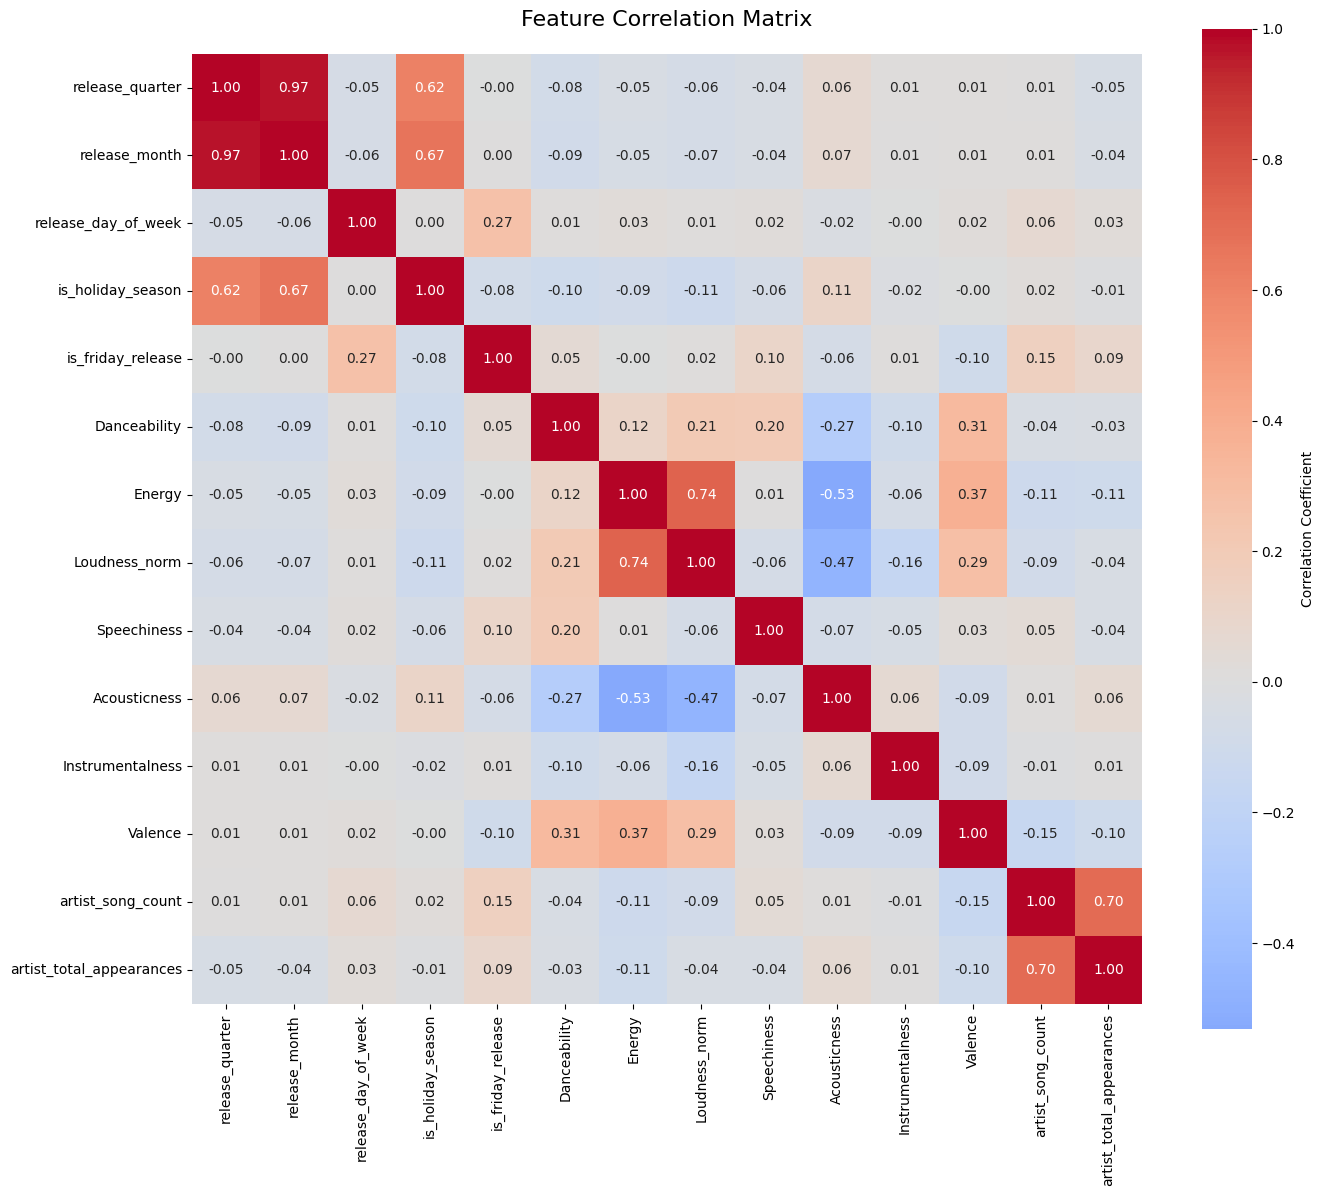

In [513]:
def plot_correlation_matrix(corr_matrix):
    """Create heatmap of correlations"""
    
    plt.figure(figsize=(14, 12))
    
    # Create heatmap
    sns.heatmap(corr_matrix, 
                annot=True,           # Show correlation values
                cmap='coolwarm',     # Color scheme
                center=0,            # Center at 0
                fmt='.2f',           # Format to 2 decimals
                square=True,           # Make cells square
                cbar_kws={'label': 'Correlation Coefficient'})
    
    plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

plot_correlation_matrix(correlation_matrix)


In [514]:
def fix_threshold_optimization():
    """Find optimal threshold to maximize F1"""
    
    print("🎯 FIX 1: THRESHOLD OPTIMIZATION")
    print("=" * 60)
    
    # Use your best model (Random Forest)
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.preprocessing import StandardScaler
    
    # Simple pipeline without SMOTE for threshold testing
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(sorted_X)
    X_test_scaled = scaler.transform(sorted_X)
    
    rf = models['XGBoost']
    rf.fit(X_train_scaled, sorted_y)
    
    # Get probabilities on test set
    y_pred_proba = rf.predict_proba(X_test_scaled)[:, 1]
    
    # Test different thresholds
    from sklearn.metrics import f1_score, precision_score, recall_score
    
    thresholds = np.arange(0.1, 0.9, 0.05)
    results = []
    
    print("Testing different thresholds:")
    for threshold in thresholds:
        y_pred = (y_pred_proba >= threshold).astype(int)
        
        f1 = f1_score(sorted_y, y_pred)
        precision = precision_score(sorted_y, y_pred)
        recall = recall_score(sorted_y, y_pred)
        accuracy = (y_pred == sorted_y).mean()
        
        results.append({
            'Threshold': threshold,
            'F1': f1,
            'Precision': precision,
            'Recall': recall,
            'Accuracy': accuracy,
            'Predictions': y_pred.sum(),
            'Popular_Predictions': y_pred.sum() / len(y_pred)
        })
        
        print(f"  Threshold {threshold:.2f}: F1={f1:.3f}, Precision={precision:.3f}, Recall={recall:.3f}")
    
    # Find best threshold
    results_df = pd.DataFrame(results)
    best_threshold = results_df.loc[results_df['F1'].idxmax()]
    
    print(f"\n🎉 OPTIMAL THRESHOLD: {best_threshold['Threshold']:.2f}")
    print(f"Best F1 Score: {best_threshold['F1']:.3f}")
    print(f"Improvement over 0.5: {best_threshold['F1'] - 0.51:.3f}")
    
    return best_threshold, results_df

optimal_threshold, threshold_analysis = fix_threshold_optimization()


🎯 FIX 1: THRESHOLD OPTIMIZATION
Testing different thresholds:
  Threshold 0.10: F1=0.648, Precision=0.479, Recall=0.999
  Threshold 0.15: F1=0.711, Precision=0.553, Recall=0.997
  Threshold 0.20: F1=0.767, Precision=0.624, Recall=0.995
  Threshold 0.25: F1=0.813, Precision=0.694, Recall=0.983
  Threshold 0.30: F1=0.854, Precision=0.761, Recall=0.972
  Threshold 0.35: F1=0.882, Precision=0.821, Recall=0.954
  Threshold 0.40: F1=0.898, Precision=0.867, Recall=0.932
  Threshold 0.45: F1=0.903, Precision=0.907, Recall=0.899
  Threshold 0.50: F1=0.895, Precision=0.945, Recall=0.851
  Threshold 0.55: F1=0.875, Precision=0.967, Recall=0.799
  Threshold 0.60: F1=0.832, Precision=0.983, Recall=0.721
  Threshold 0.65: F1=0.777, Precision=0.991, Recall=0.639
  Threshold 0.70: F1=0.702, Precision=0.996, Recall=0.542
  Threshold 0.75: F1=0.608, Precision=0.999, Recall=0.437
  Threshold 0.80: F1=0.483, Precision=1.000, Recall=0.318
  Threshold 0.85: F1=0.341, Precision=1.000, Recall=0.206

🎉 OPTIMAL